In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates
from AnalysisTools.DBManager import MarketDB

/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [17]:
def evaluate(df, start_date, end_date):
    df = df[start_date:end_date].copy()

    # 일별 수익률, 누적 수익률 계산
    df['daily_rtn'] = df['close'].pct_change()
    df['acc_rtn'] = (1.+df['daily_rtn']).cumprod()
    historical_max = df['close'].cummax()
    daily_drawdown = df['close']/historical_max - 1.
    historical_dd = daily_drawdown.cummin()

    CAGR = df['acc_rtn'].iloc[-1]**(252./len(df.index)) - 1.
    MDD = historical_dd.min()
    VOL = np.std(df['daily_rtn'])*np.sqrt(252.)                                     # 주가의 변동폭은 시간의 제곱근에 비례
    Sharpe = (np.mean(df['daily_rtn'])/np.std(df['daily_rtn'])*np.sqrt(252.))       # 연율화된 sharpe ratio # unacceptable

    print("==== Buy And Hold ====")
    print("CAGR:", round(CAGR*100, 2), "%")
    print("MDD:", round(MDD*100, 2), "%")
    print("VOL:", round(VOL*100, 2), "%")
    print("Sharpe:", round(Sharpe*100, 2), "%")

In [18]:
def bollinger_maker(df, n=20, var=2):
    bb = df.copy()
    bb['number'] = bb.index.map(mdates.date2num)
    bb['center'] = bb.close.rolling(window=n).mean()
    bb['upper'] = bb.center + var*bb.close.rolling(window=n).std()
    bb['lower'] = bb.center - var*bb.close.rolling(window=n).std()
    bb['PB'] = (bb.close - bb.lower)/(bb.upper - bb.lower)
    bb = bb[['number', 'center', 'upper', 'lower', 'PB']]
    return bb.dropna()

In [19]:
# Get dataset
etf = "TIGER 미국나스닥100"
#etf = "KODEX 200"
# Cushion data
start_date = "2016-01-01"
end_date = "2021-10-25"
df = MarketDB("ETF").get_daily_price(etf, start_date, end_date)
# MA 200 and EMA 130
# Always trade when close is above MA 200
df['MA200'] = df.close.rolling(window=200).mean()
df['EMA130'] = df.close.ewm(span=130).mean()
bollinger = bollinger_maker(df)

# change date datatype
# and slice the dataset with respect to the preference
start_date = datetime.strptime('2017-01-01', '%Y-%m-%d').date()
end_date = datetime.strptime('2021-10-25', '%Y-%m-%d').date()
df = df[start_date: end_date]
df['number'] = df.index.map(mdates.date2num)
ohlc = df[['number', 'open', 'high', 'low', 'close']]
bollinger = bollinger[start_date:end_date]

==== Buy And Hold ====
CAGR: 26.59 %
MDD: -25.95 %
VOL: 19.19 %
Sharpe: 132.64 %


/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/p

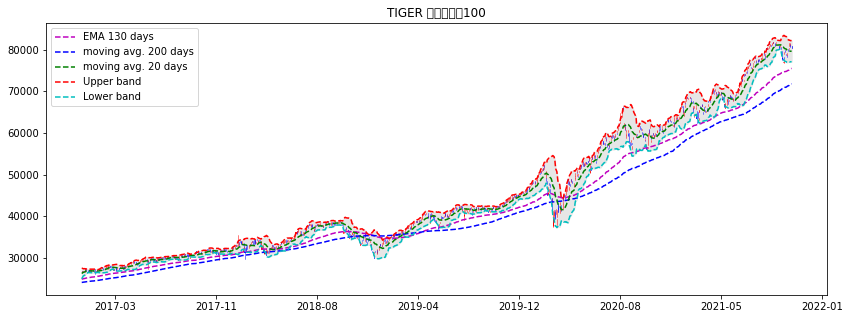

In [20]:
# Buy and hold
plt.figure(figsize=(14, 5))
p1 = plt.subplot(1, 1, 1)
# plot candlesticks
plt.title(etf)
candlestick_ohlc(p1, ohlc.values, width=.8, colorup='red', colordown='blue')
p1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(df.number, df.EMA130, 'm--', label="EMA 130 days")
plt.plot(df.number, df.MA200, 'b--', label="moving avg. 200 days")
# bollinger band
plt.plot(bollinger.number, bollinger.center, 'g--', label="moving avg. 20 days")
plt.plot(bollinger.number, bollinger.upper, 'r--', label='Upper band')
plt.plot(bollinger.number, bollinger.lower, 'c--', label='Lower band')
plt.fill_between(bollinger.number, bollinger.upper, bollinger.lower, color='0.9')
plt.legend(loc='best')
#plt.grid(True)

# evaluate buy and hold strategy
evaluate(df, start_date, end_date)

In [21]:
def trade_book_maker(sample):
    # sample should already been sliced with respect to actual trading dates
    book = sample[['close']].copy()
    book['number'] = book.index.map(mdates.date2num)
    book['trade'] = ''
    return book

In [22]:
def strategy(sample, bollinger, book):
    # All three dataframe share the index
    for date in book.index:
        # buy when the price is abvoe EMA 130 and PB > 0.8
        if book.loc[date, 'close'] > sample.loc[date, "EMA130"] and bollinger.loc[date, 'PB'] > 0.8:
            book.loc[date, 'trade'] = 'buy'
        # sell when PB < 0.2 
        elif bollinger.loc[date, 'PB'] < 0.2:
            book.loc[date, 'trade'] = ''
        else:                                             
            if date == book.index[0]:
                book.loc[date, 'trade'] = ''
            else:
                book.loc[date, 'trade'] = book.shift(1).loc[date, 'trade']

In [23]:
def evaluate(book):
    # 수익률 계산
    rtn = 1.0
    book['rtn'] = 1.
    buy = 0.
    sell = 0.
    for date in book.index:
        # long 진입
        if (date == book.index[0] and book.loc[date, 'trade'] == 'buy') or (book.loc[date, 'trade'] == 'buy' and book.shift(1).loc[date, 'trade'] == ''):
            buy = book.loc[date, 'close']
            print("[Long] 진입일:", date, "진입가격:", buy)
        # long 청산
        elif book.loc[date, 'trade'] == '' and book.shift(1).loc[date, 'trade'] == 'buy':
            sell = book.loc[date, 'close']
            rtn = (sell-buy) / buy + 1.
            book.loc[date, 'rtn'] = rtn
            print("[Long] 청산일:", date, "청산가격:", sell, "수익률:", round((rtn-1.)*100, 2), "%")
        elif book.loc[date, 'trade'] == '':     # Prepare next trading
            buy = 0.
            sell = 0.
    
    # 누적 수익률
    acc_rtn = 1.
    for date in book.index:
        rtn = book.loc[date, 'rtn']
        acc_rtn *= rtn
        book.loc[date, 'acc_rtn'] = acc_rtn
    CAGR = book['acc_rtn'].iloc[-1]**(252./len(book.index)) - 1.

    historical_max = book['acc_rtn'].cummax()
    daily_drawdown = book['acc_rtn']/historical_max - 1.
    historical_dd = daily_drawdown.cummin()
    MDD = historical_dd.min()

    print("==== Strategy: Bollinger ====")
    print("Accumulated Returns:", round((acc_rtn-1.)*100, 2), "%")
    print("CAGR:", round(CAGR*100, 2), "%")
    print("MDD:", round(MDD*100, 2), "%")

In [24]:
book = trade_book_maker(df)
strategy(df, bollinger, book)
evaluate(book)

[Long] 진입일: 2017-01-09 진입가격: 27300
[Long] 청산일: 2017-01-18 청산가격: 26595 수익률: -2.58 %
[Long] 진입일: 2017-02-10 진입가격: 27150
[Long] 청산일: 2017-03-20 청산가격: 27420 수익률: 0.99 %
[Long] 진입일: 2017-04-10 진입가격: 28030
[Long] 청산일: 2017-07-04 청산가격: 29120 수익률: 3.89 %
[Long] 진입일: 2017-07-20 진입가격: 30140
[Long] 청산일: 2017-08-21 청산가격: 29835 수익률: -1.01 %
[Long] 진입일: 2017-09-01 진입가격: 30475
[Long] 청산일: 2017-09-26 청산가격: 30225 수익률: -0.82 %
[Long] 진입일: 2017-09-28 진입가격: 30935
[Long] 청산일: 2017-11-30 청산가격: 30950 수익률: 0.05 %
[Long] 진입일: 2017-12-12 진입가격: 31745
[Long] 청산일: 2018-01-02 청산가격: 30895 수익률: -2.68 %
[Long] 진입일: 2018-01-08 진입가격: 32125
[Long] 청산일: 2018-02-06 청산가격: 32090 수익률: -0.11 %
[Long] 진입일: 2018-02-27 진입가격: 33970
[Long] 청산일: 2018-03-23 청산가격: 32635 수익률: -3.93 %
[Long] 진입일: 2018-04-18 진입가격: 32930
[Long] 청산일: 2018-10-08 청산가격: 38000 수익률: 15.4 %
[Long] 진입일: 2019-02-07 진입가격: 35190
[Long] 청산일: 2019-05-23 청산가격: 39315 수익률: 11.72 %
[Long] 진입일: 2019-06-19 진입가격: 40270
[Long] 청산일: 2019-08-06 청산가격: 40470 수익률: 0.5 %
[Long] 진입일

/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/IPython/core/p

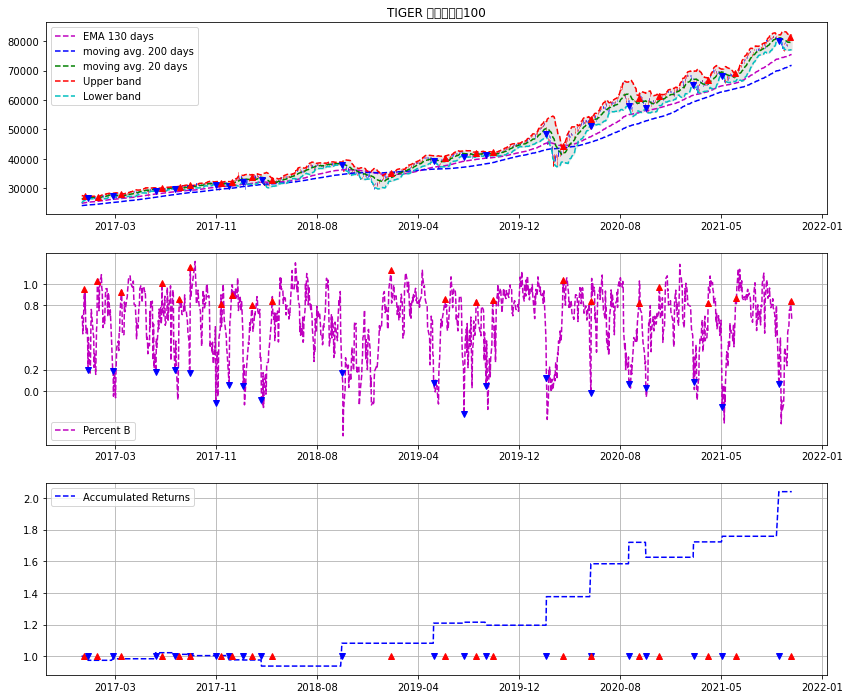

In [25]:
plt.figure(figsize=(14, 12))
p1 = plt.subplot(3, 1, 1)
# plot candlesticks
plt.title(etf)
candlestick_ohlc(p1, ohlc.values, width=.8, colorup='red', colordown='blue')
p1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(df.number, df.EMA130, 'm--', label="EMA 130 days")
plt.plot(df.number, df.MA200, 'b--', label="moving avg. 200 days")

# bollinger band
plt.plot(bollinger.number, bollinger.center, 'g--', label="moving avg. 20 days")
plt.plot(bollinger.number, bollinger.upper, 'r--', label='Upper band')
plt.plot(bollinger.number, bollinger.lower, 'c--', label='Lower band')
plt.fill_between(bollinger.number, bollinger.upper, bollinger.lower, color='0.9')
for i in range(len(book.index)):
    date = book.index[i]
    if (date == book.index[0] and book.loc[date, 'trade'] == 'buy') or (book.loc[date, 'trade'] == 'buy' and book.shift(1).loc[date, 'trade'] == ''):
        plt.plot(book.number.values[i], book.close.values[i], 'r^')
    elif book.loc[date, 'trade'] == '' and book.shift(1).loc[date, 'trade'] == 'buy':
        plt.plot(book.number.values[i], book.close.values[i], 'bv')
    else:
        continue
plt.legend(loc='best')

p2 = plt.subplot(3, 1, 2)
p2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(bollinger.number, bollinger.PB, 'm--', label="Percent B")
for i in range(len(book.index)):
    date = book.index[i]
    if (date == book.index[0] and book.loc[date, 'trade'] == 'buy') or (book.loc[date, 'trade'] == 'buy' and book.shift(1).loc[date, 'trade'] == ''):
        plt.plot(bollinger.number.values[i], bollinger.PB.values[i], 'r^')
    elif book.loc[date, 'trade'] == '' and book.shift(1).loc[date, 'trade'] == 'buy':
        plt.plot(bollinger.number.values[i], bollinger.PB.values[i], 'bv')
    else:
        continue
plt.legend(loc='best')
plt.grid(True)
plt.yticks([0., 0.2, 0.8, 1.0])

p3 = plt.subplot(3, 1, 3)
p3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(book.number, book.acc_rtn, 'b--', label="Accumulated Returns")
for i in range(len(book.index)):
    date = book.index[i]
    if (date == book.index[0] and book.loc[date, 'trade'] == 'buy') or (book.loc[date, 'trade'] == 'buy' and book.shift(1).loc[date, 'trade'] == ''):
        plt.plot(book.number.values[i], 1., 'r^')
    elif book.loc[date, 'trade'] == '' and book.shift(1).loc[date, 'trade'] == 'buy':
        plt.plot(book.number.values[i], 1., 'bv')
    else:
        continue
plt.legend(loc='best')
plt.grid(True)
plt.show()